<a href="https://colab.research.google.com/github/yxngwei/evolutionary-game-simulation/blob/main/simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
"""
game.py

Defines the payoff rules for the Prisoner's Dilemma.

Two players each choose to COOPERATE or DEFECT.
The payoff table below is the classic textbook version:

                Other: Cooperate    Other: Defect
You: Cooperate        3, 3               0, 5
You: Defect           5, 0               1, 1

Rule of thumb for why this is a "dilemma":
- No matter what the other player does, YOU personally score higher by
  defecting (5>3 if they cooperate, 1>0 if they defect).
- But if BOTH players think that way, both defect and both get only 1,
  instead of both getting 3 by cooperating. Individually rational,
  collectively worse off.
"""

COOPERATE = "C"
DEFECT = "D"

# payoff[my_move][their_move] = my_score
PAYOFF = {
    COOPERATE: {COOPERATE: 3, DEFECT: 0},
    DEFECT: {COOPERATE: 5, DEFECT: 1},
}


def play_round(move_a, move_b):
    """Return (score_a, score_b) for one round given both players' moves."""
    score_a = PAYOFF[move_a][move_b]
    score_b = PAYOFF[move_b][move_a]
    return score_a, score_b


def play_match(strategy_a, strategy_b, rounds=10):
    """
    Play an ITERATED match: the same two strategies play multiple rounds
    in a row, each remembering the full history so far (needed for
    strategies like Tit-for-Tat that react to the opponent's last move).

    strategy_a / strategy_b: functions with signature
        move = strategy(my_history, their_history)
    where my_history/their_history are lists of past moves (empty on round 1).

    Returns (total_score_a, total_score_b) summed across all rounds.
    """
    history_a, history_b = [], []
    total_a, total_b = 0, 0

    for _ in range(rounds):
        move_a = strategy_a(history_a, history_b)
        move_b = strategy_b(history_b, history_a)

        score_a, score_b = play_round(move_a, move_b)
        total_a += score_a
        total_b += score_b

        history_a.append(move_a)
        history_b.append(move_b)

    return total_a, total_b

In [77]:
"""
population.py

Defines a few simple strategies, and the replicator dynamics rule that
decides how the population's mix of strategies shifts each generation.
"""

import numpy as np
# from game import COOPERATE, DEFECT, play_match


# --- STRATEGIES -------------------------------------------------------
# Each strategy is a function: strategy(my_history, their_history) -> move
# my_history/their_history are lists of past moves in THIS match so far.

def always_cooperate(my_history, their_history):
    return COOPERATE


def always_defect(my_history, their_history):
    return DEFECT


def tit_for_tat(my_history, their_history):
    """Cooperate first, then copy whatever the opponent did last round."""
    if not their_history:
        return COOPERATE
    return their_history[-1]


STRATEGIES = {
    "Always Cooperate": always_cooperate,
    "Always Defect": always_defect,
    "Tit-for-Tat": tit_for_tat,
}

STRATEGY_NAMES = list(STRATEGIES.keys())


# --- REPLICATOR DYNAMICS ------------------------------------------------

def average_payoffs(population_shares, rounds_per_match=10):
    """
    Given the current share of the population using each strategy
    (a dict: name -> fraction, fractions sum to 1), compute the AVERAGE
    score each strategy earns when playing against the whole population
    (weighted by how common each opponent strategy currently is).

    This is the key "who's doing well right now" calculation.
    """
    avg_scores = {}

    for name_a, strategy_a in STRATEGIES.items():
        expected_score = 0.0

        for name_b, strategy_b in STRATEGIES.items():
            share_b = population_shares[name_b]
            if share_b == 0:
                continue

            total_a, _ = play_match(strategy_a, strategy_b, rounds=rounds_per_match)
            avg_score_this_matchup = total_a / rounds_per_match

            # Weight by how likely this opponent is to be encountered
            expected_score += share_b * avg_score_this_matchup

        avg_scores[name_a] = expected_score

    return avg_scores


def replicator_step(population_shares, rounds_per_match=10):
    """
    One generation of replicator dynamics:
    strategies that scored ABOVE the population average grow their share,
    strategies BELOW average shrink. This is the standard replicator
    equation from evolutionary game theory.
    """
    scores = average_payoffs(population_shares, rounds_per_match)
    mean_score = sum(population_shares[name] * scores[name] for name in STRATEGY_NAMES)

    new_shares = {}
    for name in STRATEGY_NAMES:
        # Standard replicator equation: growth proportional to relative fitness
        new_shares[name] = population_shares[name] * (scores[name] / mean_score)

    # Normalize so shares still sum to exactly 1 (guards against float drift)
    total = sum(new_shares.values())
    return {name: value / total for name, value in new_shares.items()}


def run_simulation(generations=100, rounds_per_match=10, seed=None):
    """
    Run the full simulation starting from an equal 3-way split and
    return a history: a list of dicts (one per generation) showing the
    population share of each strategy at that point in time.
    """
    if seed is not None:
        np.random.seed(seed)

    shares = {name: 1 / len(STRATEGY_NAMES) for name in STRATEGY_NAMES}
    history = [shares.copy()]

    for _ in range(generations):
        shares = replicator_step(shares, rounds_per_match)
        history.append(shares.copy())

    return history


Final population mix after 100 generations:
  Always Cooperate    :  13.9%
  Always Defect       :   0.0%
  Tit-for-Tat         :  86.1%


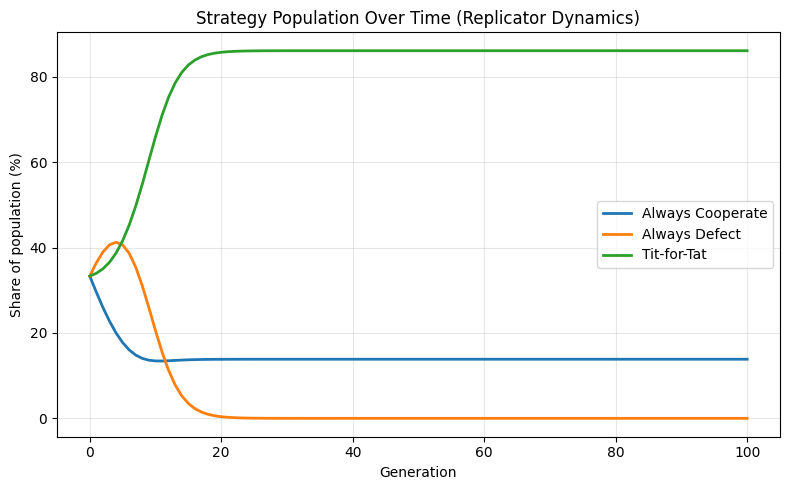

In [64]:
"""
simulate.py

Run this file to:
1. Simulate the population evolving over many generations
2. Print the final equilibrium mix
3. Save a plot showing how the strategy mix changed over time

Usage:
    python simulate.py
"""

import matplotlib.pyplot as plt
# from population import run_simulation, STRATEGY_NAMES

GENERATIONS = 100
ROUNDS_PER_MATCH = 10


def main():
    history = run_simulation(generations=GENERATIONS, rounds_per_match=ROUNDS_PER_MATCH)

    # --- Print the final result ---
    final = history[-1]
    print("\nFinal population mix after {} generations:".format(GENERATIONS))
    for name in STRATEGY_NAMES:
        print(f"  {name:20s}: {final[name] * 100:5.1f}%")

    # --- Build the plot ---
    generations_axis = list(range(len(history)))

    plt.figure(figsize=(8, 5))
    for name in STRATEGY_NAMES:
        series = [gen[name] * 100 for gen in history]
        plt.plot(generations_axis, series, label=name, linewidth=2)

    plt.xlabel("Generation")
    plt.ylabel("Share of population (%)")
    plt.title("Strategy Population Over Time (Replicator Dynamics)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = "../results/strategy_convergence.png"
    import os
    os.makedirs("../results", exist_ok=True)
    plt.show()
    # plt.savefig(output_path, dpi=150)
    # print(f"\nPlot saved to {output_path}")


if __name__ == "__main__":
    main()


Simulated equilibrium cooperation rate: 100.0%
Real-world early-round benchmark:        ~50% (Zelmer, 2003)
Real-world late-round benchmark:         ~15% (Zelmer, 2003)


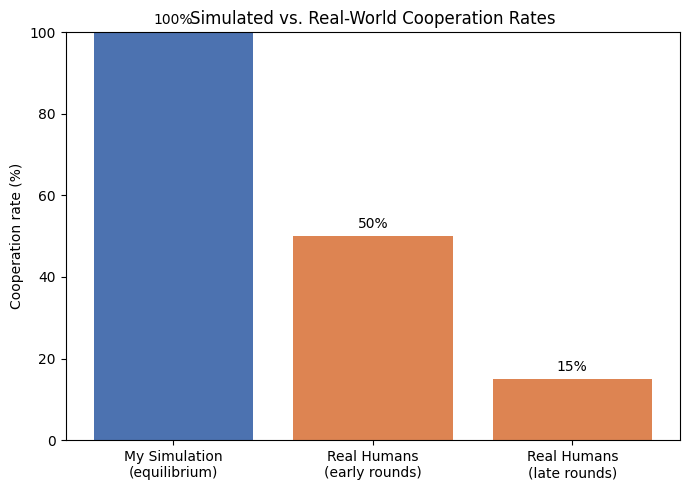

In [65]:
"""
compare.py

Computes the ACTUAL cooperation rate from the final simulated population
(not just strategy share), then compares it against a real-world benchmark
from public goods game experiments.
"""

import matplotlib.pyplot as plt
# from game import COOPERATE, play_match
# from population import run_simulation, STRATEGIES, STRATEGY_NAMES

GENERATIONS = 100
ROUNDS_PER_MATCH = 10

# Real-world benchmark (Zelmer, 2003 meta-analysis of public goods experiments)
REAL_WORLD_EARLY_ROUND_RATE = 50   # midpoint of the commonly cited 40-60% range
REAL_WORLD_LATE_ROUND_RATE = 15    # midpoint of the commonly cited 10-20% range


def cooperation_rate(population_shares, rounds_per_match=ROUNDS_PER_MATCH, samples=2000):
    """
    Estimate the actual % of individual MOVES that are Cooperate, given a
    population mix. Randomly pairs up strategies (weighted by their share)
    and counts how many of the resulting moves were 'C'.
    """
    import random
    names = STRATEGY_NAMES
    weights = [population_shares[n] for n in names]

    total_moves = 0
    cooperate_moves = 0

    for _ in range(samples):
        name_a, name_b = random.choices(names, weights=weights, k=2)
        strat_a, strat_b = STRATEGIES[name_a], STRATEGIES[name_b]

        history_a, history_b = [], []
        for _ in range(rounds_per_match):
            move_a = strat_a(history_a, history_b)
            move_b = strat_b(history_b, history_a)
            history_a.append(move_a)
            history_b.append(move_b)

            total_moves += 2
            cooperate_moves += (move_a == COOPERATE) + (move_b == COOPERATE)

    return 100 * cooperate_moves / total_moves


def main():
    history = run_simulation(generations=GENERATIONS, rounds_per_match=ROUNDS_PER_MATCH)
    final_shares = history[-1]

    sim_rate = cooperation_rate(final_shares)

    print(f"\nSimulated equilibrium cooperation rate: {sim_rate:.1f}%")
    print(f"Real-world early-round benchmark:        ~{REAL_WORLD_EARLY_ROUND_RATE}% (Zelmer, 2003)")
    print(f"Real-world late-round benchmark:         ~{REAL_WORLD_LATE_ROUND_RATE}% (Zelmer, 2003)")

    # --- comparison bar chart ---
    labels = ["My Simulation\n(equilibrium)", "Real Humans\n(early rounds)", "Real Humans\n(late rounds)"]
    values = [sim_rate, REAL_WORLD_EARLY_ROUND_RATE, REAL_WORLD_LATE_ROUND_RATE]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=["#4C72B0", "#DD8452", "#DD8452"])
    plt.ylabel("Cooperation rate (%)")
    plt.title("Simulated vs. Real-World Cooperation Rates")
    plt.ylim(0, 100)
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, value + 2, f"{value:.0f}%", ha="center")
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/cooperation_comparison.png", dpi=150)
    # print("\nComparison chart saved to ../results/cooperation_comparison.png")


if __name__ == "__main__":
    main()

In [66]:
"""
extended_strategies.py

Adds two more strategies commonly discussed in the literature, on top of
the original three:

- Grim Trigger: cooperates until the opponent EVER defects, then defects
  forever after (unforgiving).
- Generous Tit-for-Tat: like Tit-for-Tat, but forgives a defection with
  some probability instead of always retaliating (robust to noise/mistakes).
"""

import random
# from game import COOPERATE, DEFECT
# from population import always_cooperate, always_defect, tit_for_tat


GENEROSITY = 0.1  # 10% chance of forgiving a defection instead of retaliating


def grim_trigger(my_history, their_history):
    if DEFECT in their_history:
        return DEFECT
    return COOPERATE


def generous_tit_for_tat(my_history, their_history):
    if not their_history:
        return COOPERATE
    if their_history[-1] == DEFECT and random.random() < GENEROSITY:
        return COOPERATE  # forgive
    return their_history[-1]

EXTENDED_STRATEGIES = {
    "Always Cooperate": always_cooperate,
    "Always Defect": always_defect,
    "Tit-for-Tat": tit_for_tat,
    "Grim Trigger": grim_trigger,
    "Generous Tit-for-Tat": generous_tit_for_tat,
}
EXTENDED_STRATEGY_NAMES = list(EXTENDED_STRATEGIES.keys())

In [67]:
"""
noisy_game.py

Generalized version of the simulation that supports:
1. Any set of strategies (so we can plug in EXTENDED_STRATEGIES)
2. Noise: a probability that a player's intended move accidentally flips
   (simulating real-world mistakes/trembling hands)

This lets us test "what I'd explore next" item #2: does Tit-for-Tat (and
friends) stay dominant once mistakes are possible, or does its rigid
retaliation spiral into destructive feuds?
"""

import random
# from game import COOPERATE, DEFECT, play_round


def play_match_noisy(strategy_a, strategy_b, rounds=10, noise=0.0):
    history_a, history_b = [], []
    total_a, total_b = 0, 0

    for _ in range(rounds):
        move_a = strategy_a(history_a, history_b)
        move_b = strategy_b(history_b, history_a)

        # Apply noise: with probability `noise`, the intended move flips
        if random.random() < noise:
            move_a = DEFECT if move_a == COOPERATE else COOPERATE
        if random.random() < noise:
            move_b = DEFECT if move_b == COOPERATE else COOPERATE

        score_a, score_b = play_round(move_a, move_b)
        total_a += score_a
        total_b += score_b
        history_a.append(move_a)
        history_b.append(move_b)

    return total_a, total_b


def average_payoffs_noisy(population_shares, strategies, rounds_per_match=10, noise=0.0):
    names = list(strategies.keys())
    avg_scores = {}
    for name_a in names:
        expected = 0.0
        for name_b in names:
            share_b = population_shares[name_b]
            if share_b == 0:
                continue
            total_a, _ = play_match_noisy(strategies[name_a], strategies[name_b], rounds_per_match, noise)
            expected += share_b * (total_a / rounds_per_match)
        avg_scores[name_a] = expected
    return avg_scores


def replicator_step_noisy(population_shares, strategies, rounds_per_match=10, noise=0.0):
    names = list(strategies.keys())
    scores = average_payoffs_noisy(population_shares, strategies, rounds_per_match, noise)
    mean_score = sum(population_shares[n] * scores[n] for n in names)

    new_shares = {n: population_shares[n] * (scores[n] / mean_score) for n in names}
    total = sum(new_shares.values())
    return {n: v / total for n, v in new_shares.items()}


def run_simulation_noisy(strategies, generations=100, rounds_per_match=10, noise=0.0, seed=None):
    if seed is not None:
        random.seed(seed)
    names = list(strategies.keys())
    shares = {n: 1 / len(names) for n in names}
    history = [shares.copy()]
    for _ in range(generations):
        shares = replicator_step_noisy(shares, strategies, rounds_per_match, noise)
        history.append(shares.copy())
    return history


Final equilibrium mix at each noise level:
Noise   Always Coope  Always Defec  Tit-for-Tat   Grim Trigger  Generous Tit  
    0%    19.2%        0.0%       27.1%       27.1%       26.6%     
    1%    35.7%        0.0%       16.0%       24.3%       23.9%     
    5%    10.2%        0.0%       57.8%        1.4%       30.6%     
   10%    25.1%       18.0%       46.0%        1.9%        8.9%     
   20%     0.0%       99.7%        0.2%        0.1%        0.0%     


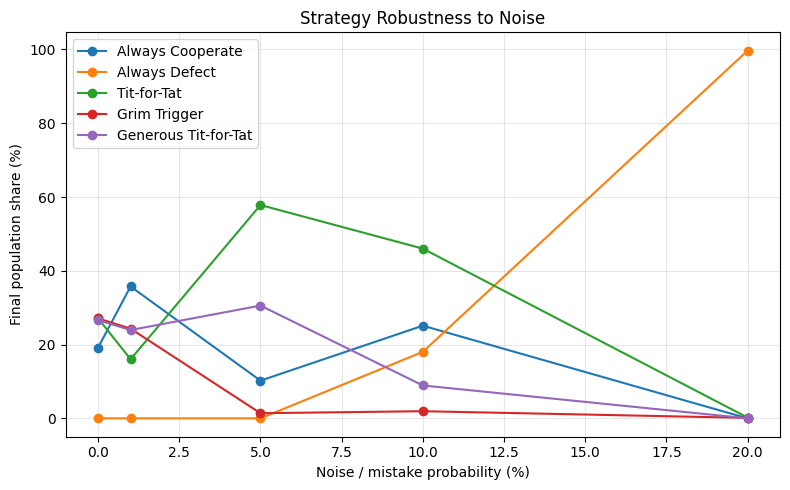

In [68]:
"""
noise_robustness.py

Runs the 5-strategy population (including Grim Trigger and Generous
Tit-for-Tat) at several noise levels, to see which strategies survive
mistakes and which collapse.
"""

import matplotlib.pyplot as plt
# from extended_strategies import EXTENDED_STRATEGIES, EXTENDED_STRATEGY_NAMES
# from noisy_game import run_simulation_noisy

NOISE_LEVELS = [0.0, 0.01, 0.05, 0.10, 0.20]
GENERATIONS = 100
ROUNDS_PER_MATCH = 10
SEED = 42


def main():
    results = {}  # noise_level -> final shares dict

    for noise in NOISE_LEVELS:
        history = run_simulation_noisy(
            EXTENDED_STRATEGIES, generations=GENERATIONS,
            rounds_per_match=ROUNDS_PER_MATCH, noise=noise, seed=SEED
        )
        results[noise] = history[-1]

    print("\nFinal equilibrium mix at each noise level:")
    header = "Noise".ljust(8) + "".join(name[:12].ljust(14) for name in EXTENDED_STRATEGY_NAMES)
    print(header)
    for noise in NOISE_LEVELS:
        row = f"{noise*100:>5.0f}%  "
        for name in EXTENDED_STRATEGY_NAMES:
            row += f"{results[noise][name]*100:>6.1f}%     "
        print(row)

    # Plot: one line per strategy, x-axis = noise level
    plt.figure(figsize=(8, 5))
    for name in EXTENDED_STRATEGY_NAMES:
        values = [results[noise][name] * 100 for noise in NOISE_LEVELS]
        plt.plot([n * 100 for n in NOISE_LEVELS], values, marker="o", label=name)

    plt.xlabel("Noise / mistake probability (%)")
    plt.ylabel("Final population share (%)")
    plt.title("Strategy Robustness to Noise")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/noise_robustness.png", dpi=150)
    # print("\nPlot saved to ../results/noise_robustness.png")


if __name__ == "__main__":
    main()


N-player Public Goods Game (group size=4, multiplier=1.6)
Final population mix:
  Free Rider              : 100.0%
  Full Cooperator         :   0.0%
  Conditional Cooperator  :   0.0%

Estimated cooperation rate (% of endowment contributed): 0.0%


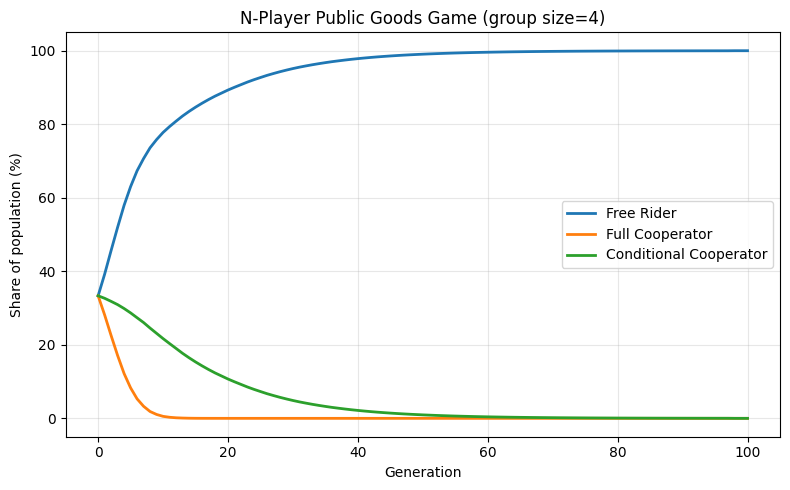

In [69]:
"""
public_goods.py

Extends the model to a TRUE N-player public goods game (the actual game
used in the real-world experiments we're comparing against), instead of
2-player Prisoner's Dilemma matches. This directly tests the hypothesis
from writeup.md: does cooperation collapse once players can't reciprocate
against one specific, identifiable partner?

Game setup (standard Voluntary Contribution Mechanism):
- Each player has an ENDOWMENT of tokens.
- Each player privately decides how much to contribute to a shared pot.
- The pot is multiplied by a factor r (1 < r < N, so the group is better
  off if everyone contributes, but each INDIVIDUAL is better off
  free-riding) and split equally among all N players regardless of
  their own contribution.
- Payoff = (endowment - my contribution) + r * (total contributions) / N

Three strategies:
- Free Rider: always contributes 0
- Full Cooperator: always contributes the full endowment
- Conditional Cooperator: contributes based on what the GROUP contributed
  on average last round (a group-level echo of Tit-for-Tat) -- this is
  the most reciprocity a player can manage when they can't target one
  specific individual.
"""

import random
import matplotlib.pyplot as plt

ENDOWMENT = 10
MULTIPLIER = 1.6     # typical value used in real public goods experiments
GROUP_SIZE = 4
ROUNDS_PER_GROUP = 10
GENERATIONS = 100
SEED = 42


def free_rider(last_group_avg_contribution):
    return 0


def full_cooperator(last_group_avg_contribution):
    return ENDOWMENT


def conditional_cooperator(last_group_avg_contribution):
    # Matches whatever the group averaged last round (starts by cooperating)
    if last_group_avg_contribution is None:
        return ENDOWMENT
    return last_group_avg_contribution


PG_STRATEGIES = {
    "Free Rider": free_rider,
    "Full Cooperator": full_cooperator,
    "Conditional Cooperator": conditional_cooperator,
}
PG_STRATEGY_NAMES = list(PG_STRATEGIES.keys())


def play_group(strategy_fns, rounds=ROUNDS_PER_GROUP):
    """
    Play one repeated public-goods game among GROUP_SIZE players (each
    using one of the given strategy functions), for `rounds` rounds.
    Returns list of total payoffs, one per player, in the same order
    as strategy_fns.
    """
    n = len(strategy_fns)
    totals = [0.0] * n
    last_avg = None

    for _ in range(rounds):
        contributions = [fn(last_avg) for fn in strategy_fns]
        pot = sum(contributions) * MULTIPLIER
        share = pot / n
        for i in range(n):
            totals[i] += (ENDOWMENT - contributions[i]) + share
        last_avg = sum(contributions) / n

    return totals


def average_payoffs(shares, samples=3000):
    """
    Estimate each strategy's average payoff by repeatedly forming random
    groups of GROUP_SIZE players drawn according to the population shares,
    and averaging the payoff each strategy earns across those groups.
    """
    names = PG_STRATEGY_NAMES
    weights = [shares[n] for n in names]

    score_sum = {n: 0.0 for n in names}
    score_count = {n: 0 for n in names}

    for _ in range(samples):
        group_names = random.choices(names, weights=weights, k=GROUP_SIZE)
        group_fns = [PG_STRATEGIES[n] for n in group_names]
        payoffs = play_group(group_fns)
        for name, payoff in zip(group_names, payoffs):
            score_sum[name] += payoff
            score_count[name] += 1

    avg = {}
    for n in names:
        avg[n] = score_sum[n] / score_count[n] if score_count[n] > 0 else 0.0
    return avg


def replicator_step(shares):
    scores = average_payoffs(shares)
    mean_score = sum(shares[n] * scores[n] for n in PG_STRATEGY_NAMES)
    new_shares = {n: shares[n] * (scores[n] / mean_score) for n in PG_STRATEGY_NAMES}
    total = sum(new_shares.values())
    return {n: v / total for n, v in new_shares.items()}


def cooperation_rate(shares, samples=3000):
    """% of ENDOWMENT actually contributed on average, at this population mix."""
    names = PG_STRATEGY_NAMES
    weights = [shares[n] for n in names]
    total_contrib = 0.0
    total_possible = 0.0
    last_avg_by_agent = None
    for _ in range(samples):
        name = random.choices(names, weights=weights, k=1)[0]
        contrib = PG_STRATEGIES[name](last_avg_by_agent)
        total_contrib += contrib
        total_possible += ENDOWMENT
    return 100 * total_contrib / total_possible


def main():
    if SEED is not None:
        random.seed(SEED)

    shares = {n: 1 / len(PG_STRATEGY_NAMES) for n in PG_STRATEGY_NAMES}
    history = [shares.copy()]
    for _ in range(GENERATIONS):
        shares = replicator_step(shares)
        history.append(shares.copy())

    final = history[-1]
    print(f"\nN-player Public Goods Game (group size={GROUP_SIZE}, multiplier={MULTIPLIER})")
    print("Final population mix:")
    for n in PG_STRATEGY_NAMES:
        print(f"  {n:24s}: {final[n]*100:5.1f}%")

    coop_rate = cooperation_rate(final)
    print(f"\nEstimated cooperation rate (% of endowment contributed): {coop_rate:.1f}%")

    # Plot population over generations
    plt.figure(figsize=(8, 5))
    gens = list(range(len(history)))
    for n in PG_STRATEGY_NAMES:
        plt.plot(gens, [g[n] * 100 for g in history], label=n, linewidth=2)
    plt.xlabel("Generation")
    plt.ylabel("Share of population (%)")
    plt.title(f"N-Player Public Goods Game (group size={GROUP_SIZE})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/public_goods_convergence.png", dpi=150)
    # print("Plot saved to ../results/public_goods_convergence.png")


if __name__ == "__main__":
    main()


Final equilibrium from different STARTING population splits:

Even split (33/33/33)            -> Always Cooperate: 13.9%, Always Defect: 0.0%, Tit-for-Tat: 86.1%
Defect-heavy (10/80/10)          -> Always Cooperate: 0.0%, Always Defect: 0.0%, Tit-for-Tat: 100.0%
Cooperate-heavy (80/10/10)       -> Always Cooperate: 0.0%, Always Defect: 100.0%, Tit-for-Tat: 0.0%
TFT-heavy (10/10/80)             -> Always Cooperate: 10.3%, Always Defect: 0.0%, Tit-for-Tat: 89.7%
No Tit-for-Tat at all (50/50/0)  -> Always Cooperate: 0.0%, Always Defect: 100.0%, Tit-for-Tat: 0.0%


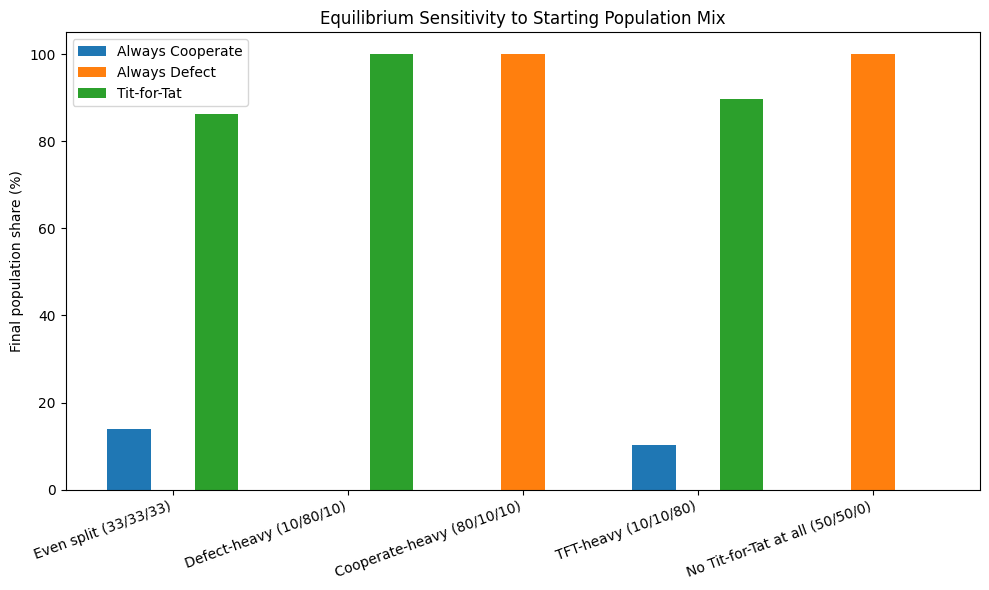

In [72]:
"""
sensitivity_analysis.py

Tests how sensitive the 2-player equilibrium (Always Cooperate / Always
Defect / Tit-for-Tat) is to (a) different random seeds and (b) different
STARTING population splits, instead of always starting from an even
33/33/33 split.
"""

import random
import matplotlib.pyplot as plt
# from population import STRATEGIES, STRATEGY_NAMES, replicator_step

GENERATIONS = 100
ROUNDS_PER_MATCH = 10

STARTING_SPLITS = {
    "Even split (33/33/33)": {"Always Cooperate": 1/3, "Always Defect": 1/3, "Tit-for-Tat": 1/3},
    "Defect-heavy (10/80/10)": {"Always Cooperate": 0.10, "Always Defect": 0.80, "Tit-for-Tat": 0.10},
    "Cooperate-heavy (80/10/10)": {"Always Cooperate": 0.80, "Always Defect": 0.10, "Tit-for-Tat": 0.10},
    "TFT-heavy (10/10/80)": {"Always Cooperate": 0.10, "Always Defect": 0.10, "Tit-for-Tat": 0.80},
    "No Tit-for-Tat at all (50/50/0)": {"Always Cooperate": 0.50, "Always Defect": 0.50, "Tit-for-Tat": 0.0},
}


def run_from(start_shares, seed=None):
    if seed is not None:
        random.seed(seed)
    shares = dict(start_shares)
    for _ in range(GENERATIONS):
        shares = replicator_step(shares, ROUNDS_PER_MATCH)
    return shares


def main():
    print("\nFinal equilibrium from different STARTING population splits:\n")
    results = {}
    for label, start in STARTING_SPLITS.items():
        final = run_from(start, seed=42)
        results[label] = final
        line = f"{label:32s} -> "
        line += ", ".join(f"{name}: {final[name]*100:.1f}%" for name in STRATEGY_NAMES)
        print(line)

    # Bar chart: one group of bars per starting condition
    fig, ax = plt.subplots(figsize=(10, 6))
    labels = list(STARTING_SPLITS.keys())
    x = range(len(labels))
    width = 0.25
    for i, name in enumerate(STRATEGY_NAMES):
        values = [results[label][name] * 100 for label in labels]
        ax.bar([xi + i * width for xi in x], values, width, label=name)

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Final population share (%)")
    ax.set_title("Equilibrium Sensitivity to Starting Population Mix")
    ax.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/sensitivity_analysis.png", dpi=150)
    # print("\nPlot saved to ../results/sensitivity_analysis.png")


if __name__ == "__main__":
    main()


N-player Public Goods with Costly Punishment (cost=1, fine=3)
  Free Rider  : 100.0%
  Cooperator  :   0.0%
  Punisher    :   0.0%

Cooperation rate (% contributing fully): 0.0%


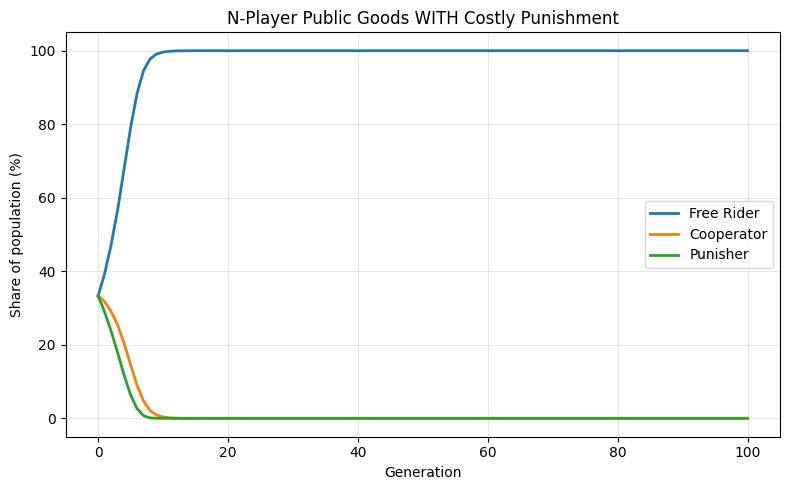

In [73]:
"""
pg_punishment.py

Adds a costly-punishment option to the N-player public goods game, to
test whether it closes the gap with Rand & Nowak (2011)'s 34% (no
punishment) / 87% (with punishment) benchmarks.

Punishment mechanics (standard experimental design, e.g. Fehr & Gachter):
- After contributions are revealed, each player may pay a cost of
  PUNISH_COST per target to inflict PUNISH_FINE damage on that target.
- Punisher strategy: contributes fully AND punishes any player whose
  contribution was below the group average that round.
- Punishing costs the punisher too, so it only pays off if punishment
  is common enough to deter free-riding at the population level.
"""

import random
import matplotlib.pyplot as plt

ENDOWMENT = 10
MULTIPLIER = 1.6
GROUP_SIZE = 4
ROUNDS_PER_GROUP = 10
GENERATIONS = 100
SEED = 42

PUNISH_COST = 1   # cost to the punisher, per target punished
PUNISH_FINE = 3   # damage inflicted on the punished player


def free_rider(_):
    return 0, False   # (contribution, will_punish)


def cooperator(_):
    return ENDOWMENT, False


def punisher(_):
    return ENDOWMENT, True  # contributes fully AND punishes below-average contributors


PUN_STRATEGIES = {
    "Free Rider": free_rider,
    "Cooperator": cooperator,
    "Punisher": punisher,
}
PUN_NAMES = list(PUN_STRATEGIES.keys())


def play_group_with_punishment(strategy_fns, rounds=ROUNDS_PER_GROUP):
    n = len(strategy_fns)
    totals = [0.0] * n

    for _ in range(rounds):
        decisions = [fn(None) for fn in strategy_fns]  # (contribution, will_punish)
        contributions = [d[0] for d in decisions]
        will_punish = [d[1] for d in decisions]

        pot = sum(contributions) * MULTIPLIER
        share = pot / n
        payoffs = [(ENDOWMENT - contributions[i]) + share for i in range(n)]

        avg_contribution = sum(contributions) / n

        # Apply punishment: each punisher pays PUNISH_COST for every
        # below-average contributor, and inflicts PUNISH_FINE on each of them
        for i in range(n):
            if not will_punish[i]:
                continue
            targets = [j for j in range(n) if j != i and contributions[j] < avg_contribution]
            payoffs[i] -= PUNISH_COST * len(targets)
            for j in targets:
                payoffs[j] -= PUNISH_FINE

        for i in range(n):
            totals[i] += payoffs[i]

    return totals


def average_payoffs(shares, samples=3000):
    names = PUN_NAMES
    weights = [shares[n] for n in names]
    score_sum = {n: 0.0 for n in names}
    score_count = {n: 0 for n in names}

    for _ in range(samples):
        group_names = random.choices(names, weights=weights, k=GROUP_SIZE)
        group_fns = [PUN_STRATEGIES[n] for n in group_names]
        payoffs = play_group_with_punishment(group_fns)
        for name, payoff in zip(group_names, payoffs):
            score_sum[name] += payoff
            score_count[name] += 1

    return {n: (score_sum[n] / score_count[n] if score_count[n] > 0 else 0.0) for n in names}


def replicator_step(shares):
    scores = average_payoffs(shares)
    mean_score = sum(shares[n] * scores[n] for n in PUN_NAMES)
    new_shares = {n: shares[n] * (scores[n] / mean_score) for n in PUN_NAMES}
    total = sum(new_shares.values())
    return {n: v / total for n, v in new_shares.items()}


def cooperation_rate(shares):
    # Cooperator and Punisher both contribute ENDOWMENT; Free Rider contributes 0
    return 100 * (shares["Cooperator"] + shares["Punisher"])


def main():
    random.seed(SEED)
    shares = {n: 1 / len(PUN_NAMES) for n in PUN_NAMES}
    history = [shares.copy()]
    for _ in range(GENERATIONS):
        shares = replicator_step(shares)
        history.append(shares.copy())

    final = history[-1]
    print(f"\nN-player Public Goods with Costly Punishment (cost={PUNISH_COST}, fine={PUNISH_FINE})")
    for n in PUN_NAMES:
        print(f"  {n:12s}: {final[n]*100:5.1f}%")
    print(f"\nCooperation rate (% contributing fully): {cooperation_rate(final):.1f}%")

    plt.figure(figsize=(8, 5))
    gens = list(range(len(history)))
    for n in PUN_NAMES:
        plt.plot(gens, [g[n] * 100 for g in history], label=n, linewidth=2)
    plt.xlabel("Generation")
    plt.ylabel("Share of population (%)")
    plt.title("N-Player Public Goods WITH Costly Punishment")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/pg_punishment_convergence.png", dpi=150)
    # print("Plot saved to ../results/pg_punishment_convergence.png")


if __name__ == "__main__":
    main()


Reputation-based N-player Public Goods Game
Final population mix (generation 60):
  Free Rider    :  78.3%
  Cooperator    :   0.0%
  Discriminator :  21.7%

Cooperation rate in final few generations: 1.4%


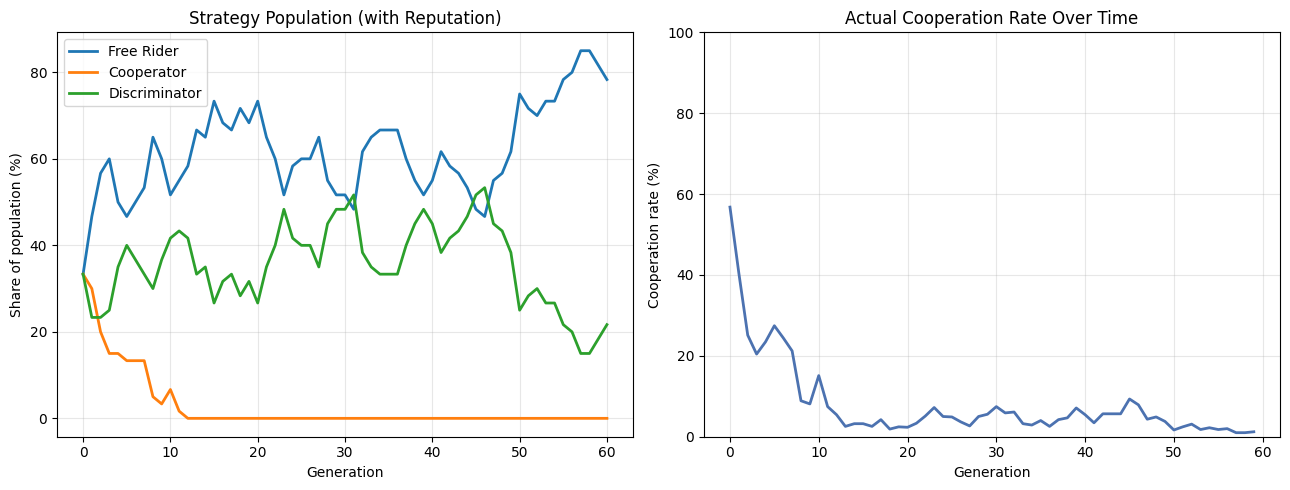

In [74]:
"""
reputation_model.py

Tests whether a PUBLIC REPUTATION system (each player's contribution
history is visible to everyone, even though group membership is
re-randomized every round) can sustain cooperation -- a middle ground
between full 1-on-1 reciprocity (my 2-player model: ~100% cooperation)
and full anonymity (my N-player model: 0% cooperation).

This is an individual agent-based model (not the population-share
abstraction used elsewhere) because reputation requires tracking each
agent's own history over many rounds within a generation.

Strategies:
- Free Rider: always contributes 0
- Cooperator: always contributes fully, regardless of reputation info
- Discriminator: looks at the AVERAGE reputation of its current
  groupmates (their fraction of past rounds spent contributing) and
  contributes fully only if that average is above REPUTATION_THRESHOLD
"""

import random
import matplotlib.pyplot as plt

ENDOWMENT = 10
MULTIPLIER = 1.6
GROUP_SIZE = 4
ROUNDS_PER_GENERATION = 15
POPULATION_SIZE = 60
GENERATIONS = 60
REPUTATION_THRESHOLD = 0.5
SEED = 42

STRATEGY_TYPES = ["Free Rider", "Cooperator", "Discriminator"]


class Agent:
    __slots__ = ["strategy", "rounds_played", "rounds_contributed", "payoff"]

    def __init__(self, strategy):
        self.strategy = strategy
        self.rounds_played = 0
        self.rounds_contributed = 0
        self.payoff = 0.0

    @property
    def reputation(self):
        if self.rounds_played == 0:
            return 0.5  # neutral prior for brand-new agents
        return self.rounds_contributed / self.rounds_played

    def decide(self, groupmates_avg_reputation):
        if self.strategy == "Free Rider":
            return 0
        if self.strategy == "Cooperator":
            return ENDOWMENT
        # Discriminator
        if groupmates_avg_reputation >= REPUTATION_THRESHOLD:
            return ENDOWMENT
        return 0


def play_generation(agents):
    for agent in agents:
        agent.payoff = 0.0
        agent.rounds_played = 0
        agent.rounds_contributed = 0

    for _ in range(ROUNDS_PER_GENERATION):
        shuffled = agents[:]
        random.shuffle(shuffled)

        for i in range(0, len(shuffled) - GROUP_SIZE + 1, GROUP_SIZE):
            group = shuffled[i:i + GROUP_SIZE]

            contributions = []
            for agent in group:
                others = [a for a in group if a is not agent]
                avg_rep = sum(a.reputation for a in others) / len(others)
                contributions.append(agent.decide(avg_rep))

            pot = sum(contributions) * MULTIPLIER
            share = pot / GROUP_SIZE

            for agent, contribution in zip(group, contributions):
                agent.payoff += (ENDOWMENT - contribution) + share
                agent.rounds_played += 1
                if contribution > 0:
                    agent.rounds_contributed += 1


def reproduce(agents):
    """Next generation's strategies are drawn proportional to total payoff
    earned this generation (standard replicator-style selection), applied
    to a finite population. New agents start with a blank reputation."""
    total_payoff = sum(max(a.payoff, 0.0001) for a in agents)
    weights = [max(a.payoff, 0.0001) / total_payoff for a in agents]
    chosen = random.choices(agents, weights=weights, k=len(agents))
    return [Agent(a.strategy) for a in chosen]


def strategy_shares(agents):
    counts = {s: 0 for s in STRATEGY_TYPES}
    for a in agents:
        counts[a.strategy] += 1
    return {s: counts[s] / len(agents) for s in STRATEGY_TYPES}


def cooperation_rate(agents):
    total_contributed = sum(a.rounds_contributed for a in agents)
    total_played = sum(a.rounds_played for a in agents)
    return 100 * total_contributed / total_played if total_played else 0.0


def main():
    random.seed(SEED)
    agents = [Agent(STRATEGY_TYPES[i % 3]) for i in range(POPULATION_SIZE)]
    random.shuffle(agents)

    history = [strategy_shares(agents)]
    coop_history = []

    for gen in range(GENERATIONS):
        play_generation(agents)
        coop_history.append(cooperation_rate(agents))
        agents = reproduce(agents)
        history.append(strategy_shares(agents))

    final = history[-1]
    print(f"\nReputation-based N-player Public Goods Game")
    print(f"Final population mix (generation {GENERATIONS}):")
    for s in STRATEGY_TYPES:
        print(f"  {s:14s}: {final[s]*100:5.1f}%")
    print(f"\nCooperation rate in final few generations: {sum(coop_history[-5:]) / 5:.1f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    gens = list(range(len(history)))
    for s in STRATEGY_TYPES:
        ax1.plot(gens, [h[s] * 100 for h in history], label=s, linewidth=2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Share of population (%)")
    ax1.set_title("Strategy Population (with Reputation)")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(range(len(coop_history)), coop_history, color="#4C72B0", linewidth=2)
    ax2.set_xlabel("Generation")
    ax2.set_ylabel("Cooperation rate (%)")
    ax2.set_title("Actual Cooperation Rate Over Time")
    ax2.set_ylim(0, 100)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/reputation_model.png", dpi=150)
    # print("Plot saved to ../results/reputation_model.png")


if __name__ == "__main__":
    main()


Fixed Always Cooperate start: 10%
Sweeping starting Tit-for-Tat share (of the remaining population):

  Starting TFT %   Starting Defect %  ->   Final TFT %
            0.0%               90.0%  ->          0.0%
            4.5%               85.5%  ->          0.0%
            9.0%               81.0%  ->        100.0%
           13.5%               76.5%  ->        100.0%
           18.0%               72.0%  ->         99.4%
           22.5%               67.5%  ->         97.9%
           27.0%               63.0%  ->         96.1%
           31.5%               58.5%  ->         94.3%
           36.0%               54.0%  ->         92.9%
           40.5%               49.5%  ->         91.7%
           45.0%               45.0%  ->         90.9%
           49.5%               40.5%  ->         90.3%
           54.0%               36.0%  ->         89.9%
           58.5%               31.5%  ->         89.7%
           63.0%               27.0%  ->         89.6%
           67.5% 

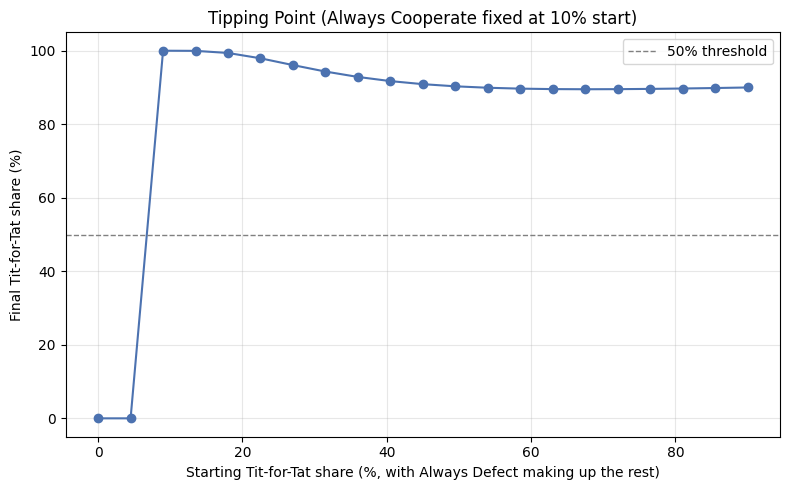

In [78]:
"""
tipping_point.py

Maps the exact tipping point: starting from a fixed small share of
Always Cooperate, how much Tit-for-Tat (vs. Always Defect) does the
population need to start with for cooperation to survive, instead of
Always Defect taking over completely?
"""

import matplotlib.pyplot as plt
# from population import STRATEGY_NAMES, replicator_step

GENERATIONS = 100
ROUNDS_PER_MATCH = 10
FIXED_COOPERATE_SHARE = 0.10  # keep this constant; vary the TFT/Defect split


def run_from(tft_fraction_of_remainder):
    """
    tft_fraction_of_remainder: of the (1 - FIXED_COOPERATE_SHARE) left over,
    what fraction starts as Tit-for-Tat vs. Always Defect.
    """
    remainder = 1 - FIXED_COOPERATE_SHARE
    shares = {
        "Always Cooperate": FIXED_COOPERATE_SHARE,
        "Tit-for-Tat": remainder * tft_fraction_of_remainder,
        "Always Defect": remainder * (1 - tft_fraction_of_remainder),
    }
    for _ in range(GENERATIONS):
        shares = replicator_step(shares, ROUNDS_PER_MATCH)
    return shares


def main():
    fractions = [i / 20 for i in range(21)]  # 0%, 5%, 10%, ..., 100%
    final_tft_shares = []

    print(f"\nFixed Always Cooperate start: {FIXED_COOPERATE_SHARE*100:.0f}%")
    print("Sweeping starting Tit-for-Tat share (of the remaining population):\n")
    print(f"{'Starting TFT %':>16s}  {'Starting Defect %':>18s}  ->  {'Final TFT %':>12s}")

    tipping_point = None
    for frac in fractions:
        final = run_from(frac)
        final_tft = final["Tit-for-Tat"] * 100
        final_tft_shares.append(final_tft)

        start_tft = frac * (1 - FIXED_COOPERATE_SHARE) * 100
        start_defect = (1 - frac) * (1 - FIXED_COOPERATE_SHARE) * 100
        print(f"{start_tft:15.1f}%  {start_defect:17.1f}%  ->  {final_tft:11.1f}%")

        if tipping_point is None and final_tft > 50:
            tipping_point = (frac, start_tft, start_defect)

    if tipping_point:
        frac, start_tft, start_defect = tipping_point
        print(f"\nTipping point found: once starting Tit-for-Tat share of the "
              f"non-cooperator population exceeds roughly {start_tft:.1f}% "
              f"(vs. {start_defect:.1f}% Defect), cooperation flips to dominant.")

    plt.figure(figsize=(8, 5))
    starting_tft_pct = [f * (1 - FIXED_COOPERATE_SHARE) * 100 for f in fractions]
    plt.plot(starting_tft_pct, final_tft_shares, marker="o", color="#4C72B0")
    plt.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% threshold")
    plt.xlabel("Starting Tit-for-Tat share (%, with Always Defect making up the rest)")
    plt.ylabel("Final Tit-for-Tat share (%)")
    plt.title(f"Tipping Point (Always Cooperate fixed at {FIXED_COOPERATE_SHARE*100:.0f}% start)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/tipping_point.png", dpi=150)
    # print("\nPlot saved to ../results/tipping_point.png")


if __name__ == "__main__":
    main()


Real-world cooperation rate by city (% of endowment contributed, period 1):

  Copenhagen      :  88.5%
  Nottingham      :  75.0%
  Seoul           :  73.5%
  Bonn            :  72.5%
  Melbourne       :  70.5%
  Chengdu         :  69.5%
  Dnipropetrovsk  :  54.5%
  Minsk           :  52.5%
  St. Gallen      :  50.5%
  Muscat          :  50.0%
  Samara          :  48.5%
  Zurich          :  46.5%
  Boston          :  46.5%
  Istanbul        :  35.5%
  Riyadh          :  34.5%
  Athens          :  28.5%

16-city average: 56.1%
My 2-player IPD model:        100.0%
My N-player public goods model: 0.0%

City closest to my 2-player (100%) extreme: Copenhagen (88.5%)
City closest to my N-player (0%) extreme:   Athens (28.5%)


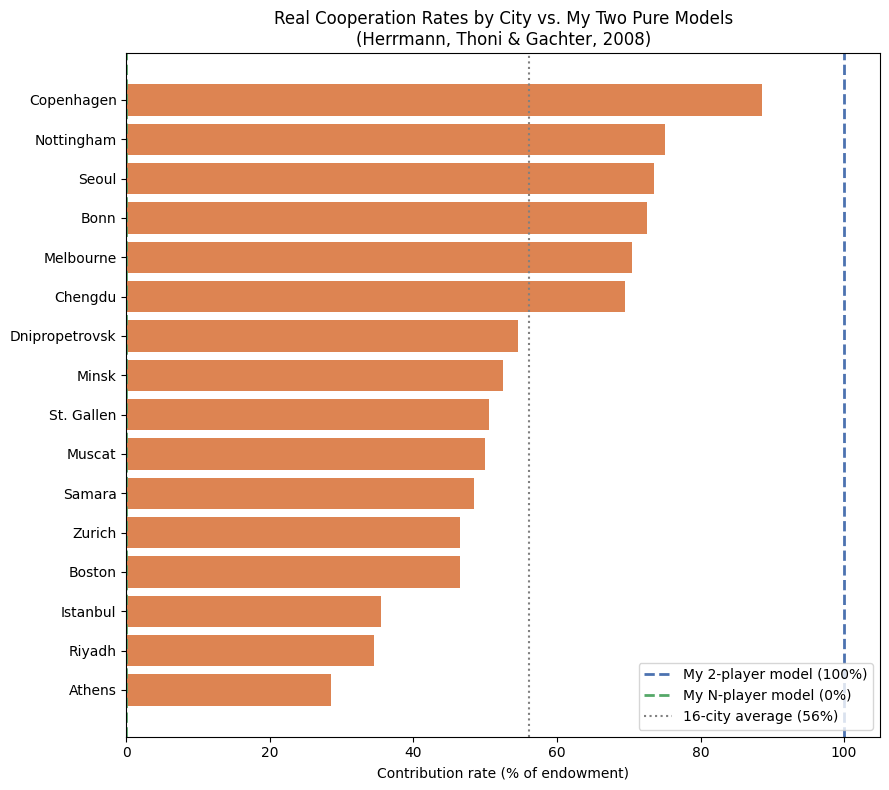

In [79]:
"""
country_comparison.py

Compares real average contribution levels from 16 cities worldwide
(Herrmann, Thoni & Gachter, 2008, Science -- period-1 contributions,
before any punishment option, out of a 20-token endowment) against my
two pure simulation extremes: the 2-player IPD model (~100% cooperation)
and the N-player public goods model (0% cooperation).
"""

import matplotlib.pyplot as plt

# Period-1 (no punishment) average contributions, out of a 20-token endowment
# Source: Herrmann, Thoni & Gachter (2008), Science, Fig. 1
CITY_CONTRIBUTIONS_OF_20 = {
    "Copenhagen": 17.7,
    "Nottingham": 15.0,
    "Seoul": 14.7,
    "Bonn": 14.5,
    "Melbourne": 14.1,
    "Chengdu": 13.9,
    "Minsk": 10.5,
    "Muscat": 10.0,
    "St. Gallen": 10.1,
    "Dnipropetrovsk": 10.9,
    "Samara": 9.7,
    "Zurich": 9.3,
    "Boston": 9.3,
    "Istanbul": 7.1,
    "Riyadh": 6.9,
    "Athens": 5.7,
}

MY_2_PLAYER_MODEL = 100.0
MY_N_PLAYER_MODEL = 0.0


def main():
    cities_pct = {city: (val / 20) * 100 for city, val in CITY_CONTRIBUTIONS_OF_20.items()}
    sorted_cities = sorted(cities_pct.items(), key=lambda x: x[1], reverse=True)

    print("\nReal-world cooperation rate by city (% of endowment contributed, period 1):\n")
    for city, pct in sorted_cities:
        print(f"  {city:16s}: {pct:5.1f}%")

    avg_across_cities = sum(cities_pct.values()) / len(cities_pct)
    print(f"\n16-city average: {avg_across_cities:.1f}%")
    print(f"My 2-player IPD model:        {MY_2_PLAYER_MODEL:.1f}%")
    print(f"My N-player public goods model: {MY_N_PLAYER_MODEL:.1f}%")

    closest_to_100 = sorted_cities[0]
    closest_to_0 = sorted_cities[-1]
    print(f"\nCity closest to my 2-player (100%) extreme: {closest_to_100[0]} ({closest_to_100[1]:.1f}%)")
    print(f"City closest to my N-player (0%) extreme:   {closest_to_0[0]} ({closest_to_0[1]:.1f}%)")

    # Plot: horizontal bar chart of all cities, with my two model lines overlaid
    fig, ax = plt.subplots(figsize=(9, 8))
    cities = [c for c, _ in sorted_cities]
    values = [v for _, v in sorted_cities]

    bars = ax.barh(cities, values, color="#DD8452")
    ax.axvline(MY_2_PLAYER_MODEL, color="#4C72B0", linestyle="--", linewidth=2,
               label=f"My 2-player model ({MY_2_PLAYER_MODEL:.0f}%)")
    ax.axvline(MY_N_PLAYER_MODEL, color="#55A868", linestyle="--", linewidth=2,
               label=f"My N-player model ({MY_N_PLAYER_MODEL:.0f}%)")
    ax.axvline(avg_across_cities, color="gray", linestyle=":", linewidth=1.5,
               label=f"16-city average ({avg_across_cities:.0f}%)")

    ax.set_xlabel("Contribution rate (% of endowment)")
    ax.set_title("Real Cooperation Rates by City vs. My Two Pure Models\n(Herrmann, Thoni & Gachter, 2008)")
    ax.legend(loc="lower right")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    # plt.savefig("../results/country_comparison.png", dpi=150)
    # print("\nPlot saved to ../results/country_comparison.png")


if __name__ == "__main__":
    main()